In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

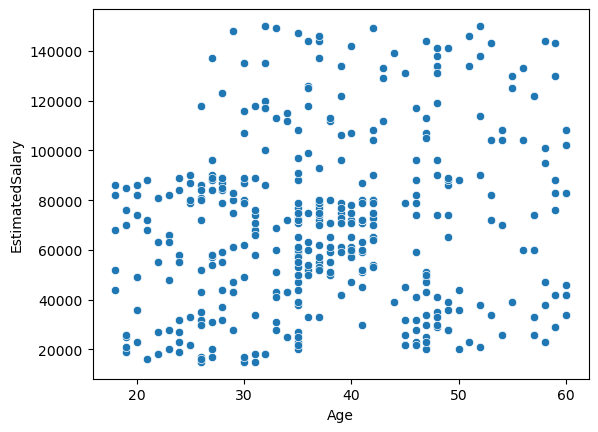

In [4]:
import seaborn as sns
sns.scatterplot(x = "Age" , y = "EstimatedSalary" , data = df)

In [5]:
x = df.drop("Purchased" , axis =1)
y = df.Purchased

In [6]:
from sklearn.model_selection import train_test_split
x_train ,x_test , y_train ,y_test = train_test_split(x,y , test_size = .2 , random_state = 42) 

In [7]:
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [8]:
model = Sequential()

model.add(Dense(128 , activation = "relu" , input_dim = 2))
model.add(Dense(1 , activation = "sigmoid"))

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 513 (2.00 KB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
model.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])

In [11]:
history = model.fit(x_train , y_train , validation_data = (x_test , y_test) ,epochs = 100)

Epoch 1/100


10/10 [==============================] - 1s 32ms/step - loss: 332.1600 - accuracy: 0.5469 - val_loss: 92.3182 - val_accuracy: 0.6500
Epoch 2/100
10/10 [==============================] - 0s 7ms/step - loss: 108.2799 - accuracy: 0.5156 - val_loss: 7.6842 - val_accuracy: 0.3500
Epoch 3/100
10/10 [==============================] - 0s 6ms/step - loss: 54.3778 - accuracy: 0.4406 - val_loss: 102.1955 - val_accuracy: 0.6500
Epoch 4/100
10/10 [==============================] - 0s 6ms/step - loss: 48.4876 - accuracy: 0.4969 - val_loss: 12.3099 - val_accuracy: 0.6500
Epoch 5/100
10/10 [==============================] - 0s 7ms/step - loss: 21.3283 - accuracy: 0.5063 - val_loss: 30.6605 - val_accuracy: 0.3500
Epoch 6/100
10/10 [==============================] - 0s 6ms/step - loss: 18.8286 - accuracy: 0.4375 - val_loss: 4.2575 - val_accuracy: 0.6500
Epoch 7/100
10/10 [==============================] - 0s 7ms/step - loss: 24.2066 - accuracy: 0.5031 - val_loss: 21.9185 - val_accuracy: 0.

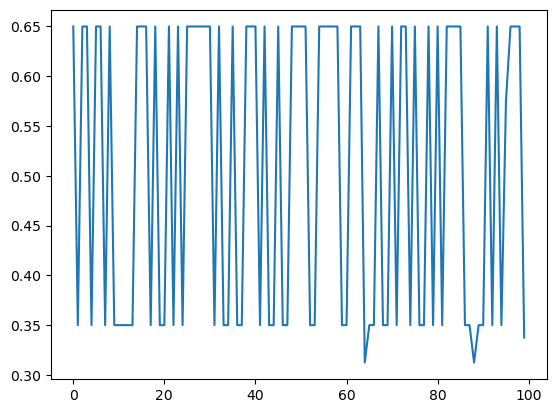

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

# applying scaling

In [13]:
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()

In [14]:
x_trained_scaled = scl.fit_transform(x_train)
x_test_scaled = scl.transform(x_test)

In [15]:
model1 = Sequential()
model1.add(Dense(128 , activation = "relu" , input_dim = 2))
model1.add(Dense(1 , activation = "sigmoid"))

In [16]:
model1.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])

In [17]:
history = model1.fit(x_trained_scaled , y_train , validation_data = (x_test_scaled , y_test) , epochs = 100)

Epoch 1/100
10/10 [==============================] - 1s 27ms/step - loss: 0.6538 - accuracy: 0.5813 - val_loss: 0.6110 - val_accuracy: 0.8500
Epoch 2/100
10/10 [==============================] - 0s 6ms/step - loss: 0.6087 - accuracy: 0.7969 - val_loss: 0.5590 - val_accuracy: 0.8750
Epoch 3/100
10/10 [==============================] - 0s 6ms/step - loss: 0.5706 - accuracy: 0.8438 - val_loss: 0.5141 - val_accuracy: 0.8750
Epoch 4/100
10/10 [==============================] - 0s 6ms/step - loss: 0.5358 - accuracy: 0.8594 - val_loss: 0.4737 - val_accuracy: 0.8875
Epoch 5/100
10/10 [==============================] - 0s 6ms/step - loss: 0.5062 - accuracy: 0.8594 - val_loss: 0.4373 - val_accuracy: 0.9125
Epoch 6/100
10/10 [==============================] - 0s 6ms/step - loss: 0.4784 - accuracy: 0.8500 - val_loss: 0.4036 - val_accuracy: 0.9125
Epoch 7/100
10/10 [==============================] - 0s 6ms/step - loss: 0.4528 - accuracy: 0.8531 - val_loss: 0.3748 - val_accuracy: 0.9250
Epoch 8/100


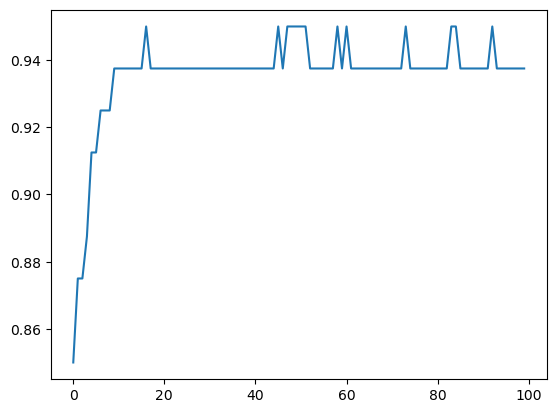

In [18]:
plt.plot(history.history['val_accuracy'])